#Curso Herramientas básicas UTN - Aaron Chaparro

### INTRODUCCIÓN
 - Análisis de E-commerce — Dataset Olist (Brasil)
### Trabajo Final — Data Analyst

---

## Introducción

El siguiente análisis fue realizado sobre el **Brazilian E-commerce Public Dataset**
de Olist, disponible públicamente en [Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

El dataset contiene información real de pedidos realizados en el marketplace
brasileño Olist entre **2016 y 2018**, incluyendo datos de órdenes, productos,
clientes, vendedores y reseñas.

---

## Pregunta de negocio

> **¿Cuáles son los factores que influyen en los tiempos de entrega y
> la satisfacción del cliente en el e-commerce de Olist?**

A partir de esta pregunta central, se busca responder:

- ¿Cuál es el volumen de ventas y su evolución temporal?
- ¿Cuánto tardan en promedio los pedidos en ser entregados?
- ¿Qué estados o regiones concentran la mayor actividad?
- ¿Existe relación entre el tiempo de entrega y la satisfacción del cliente?

---

## Datasets utilizados

| Archivo | Descripción | Filas |
|---|---|---|
| `olist_orders_dataset.csv` | Órdenes y fechas del ciclo de compra | 99.441 |
| `olist_order_items_dataset.csv` | Ítems, precios y vendedores por orden | 112.650 |
| `olist_customers_dataset.csv` | Ubicación y datos de clientes | 99.441 |

---

## Metodología

El análisis sigue un flujo de trabajo end-to-end:

1. **Inspección** — diagnóstico estructural: dimensiones, tipos de datos, valores nulos y duplicados mediante función personalizada
2. **Limpieza de datos** — tratamiento de nulos, tipos de datos y duplicados
3. **Exploración (EDA)** — distribuciones, tendencias y correlaciones
4. **Visualización** — gráficos interpretados con enfoque de negocio
5. **Dashboard en Power BI** — comunicación ejecutiva de los hallazgos

---

*Herramientas utilizadas: Python (pandas, matplotlib, seaborn) · Power BI · GitHub*

### CARGAR DATASET

In [32]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
orders = pd.read_csv('/content/drive/MyDrive/olist_orders_dataset.csv')
items = pd.read_csv('/content/drive/MyDrive/olist_order_items_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/olist_customers_dataset.csv')

In [34]:
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)


Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)


### INSPECCIÓN

In [35]:
def diagnostico(df, nombre):
    print(f"\n{'='*50}")
    print(f"  DATASET: {nombre}")
    print(f"{'='*50}")
    print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
    print(f"\n--- Tipos de datos ---")
    print(df.dtypes)
    print(f"\n--- Valores nulos ---")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ Sin nulos")
    print(f"\n--- Duplicados: {df.duplicated().sum()} filas ---")
    print(f"\n--- Primeras filas ---")
    display(df.head(3))

diagnostico(orders, "orders")
diagnostico(items, "items")
diagnostico(customers, "customers")


  DATASET: orders
Filas: 99,441  |  Columnas: 8

--- Tipos de datos ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

--- Valores nulos ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- Duplicados: 0 filas ---

--- Primeras filas ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



  DATASET: items
Filas: 112,650  |  Columnas: 7

--- Tipos de datos ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

--- Valores nulos ---
✅ Sin nulos

--- Duplicados: 0 filas ---

--- Primeras filas ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



  DATASET: customers
Filas: 99,441  |  Columnas: 5

--- Tipos de datos ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

--- Valores nulos ---
✅ Sin nulos

--- Duplicados: 0 filas ---

--- Primeras filas ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


#### Hallazgos del Diagnóstico Inicial

A partir de la inspección estructural de los tres datasets, se identificaron
los siguientes problemas de calidad de datos:

**Dataset orders:** Las cinco columnas de tipo temporal fueron cargadas como
`object` por pandas, lo que impide realizar operaciones de cálculo sobre fechas.
Se detectaron valores nulos en las columnas `order_approved_at` (160),
`order_delivered_carrier_date` (1.783) y `order_delivered_customer_date` (2.965).
Estos nulos responden a una razón de negocio — pedidos cancelados o en tránsito —
por lo que no serán eliminados de forma global, sino filtrados contextualmente
en cada análisis.

**Dataset items:** No presenta nulos ni duplicados. La columna
`shipping_limit_date` requiere conversión a tipo `datetime`.

**Dataset customers:** No presenta nulos ni duplicados. Se identificó que
`customer_zip_code_prefix` fue cargado como `int64`, lo que puede producir
pérdida del cero inicial en códigos postales. Se convertirá a `string`.
Adicionalmente, los valores de `customer_city` se encuentran en minúsculas
y serán normalizados para evitar inconsistencias en análisis geográficos.

### LIMPIEZA

In [36]:
# LIMPIEZA — Paso 1: Conversión de tipos de datos (fechas)
# ------------------------------------------------------------
# Justificación: pandas cargó las columnas temporales como
# tipo object (texto). Sin convertirlas, no es posible calcular
# diferencias de tiempo, agrupar por mes ni ordenar por fecha.
# ============================================================

date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col])

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

# Verificación
print("Tipos en orders:")
print(orders.dtypes)
print("\nTipo de shipping_limit_date:", items['shipping_limit_date'].dtype)

Tipos en orders:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Tipo de shipping_limit_date: datetime64[ns]


In [37]:
# LIMPIEZA — Paso 2: Tratamiento de valores nulos
# ------------------------------------------------------------
# Justificación: los nulos en las columnas de entrega NO son
# errores del dataset. Representan pedidos que no completaron
# el ciclo de compra (cancelados, en tránsito, no aprobados).
# Decisión: conservar el dataset completo y crear un subconjunto
# filtrado solo para análisis que requieran fechas de entrega.
# ============================================================

# Verificamos qué estados tienen esos pedidos con nulos
print("=== Distribución de order_status ===")
print(orders['order_status'].value_counts())
print()

# ¿Los nulos en entrega corresponden a pedidos no entregados?
nulos_entrega = orders[orders['order_delivered_customer_date'].isnull()]
print("=== Estados de pedidos SIN fecha de entrega ===")
print(nulos_entrega['order_status'].value_counts())

=== Distribución de order_status ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

=== Estados de pedidos SIN fecha de entrega ===
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [38]:
# LIMPIEZA — Paso 2 (continuación): decisiones sobre nulos
# ============================================================

# --- Decisión 1: Conservar el dataset completo ---
# El dataset 'orders' se mantiene intacto para análisis
# de volumen, estados y tendencias temporales.

# --- Decisión 2: Crear subconjunto limpio para análisis de entrega ---
# Filtramos pedidos 'delivered' CON fecha de entrega registrada.
# Excluimos los 8 casos inconsistentes (delivered sin fecha).
# Justificación: no es posible calcular tiempos de entrega
# sin fecha de entrega, y asumir un valor sería distorsionar
# la métrica.

orders_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notnull())
].copy()

print(f"Dataset completo:              {len(orders):,} pedidos")
print(f"Pedidos delivered con fecha:   {len(orders_delivered):,} pedidos")
print(f"Excluidos (inconsistentes):    {len(orders) - len(orders_delivered):,} pedidos")

Dataset completo:              99,441 pedidos
Pedidos delivered con fecha:   96,470 pedidos
Excluidos (inconsistentes):    2,971 pedidos


In [39]:
# --- Decisión 3: Documentar los 8 casos inconsistentes ---
# Buena práctica: no eliminar, sino registrar
# qué se excluyó y por qué.

delivered_sin_fecha = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].isnull())
]

print("=== Pedidos inconsistentes (delivered sin fecha) ===")
print(delivered_sin_fecha[['order_id', 'order_status',
                            'order_purchase_timestamp',
                            'order_delivered_customer_date']])

=== Pedidos inconsistentes (delivered sin fecha) ===
                               order_id order_status order_purchase_timestamp  \
3002   2d1e2d5bf4dc7227b3bfebb81328c15f    delivered      2017-11-28 17:44:07   
20618  f5dd62b788049ad9fc0526e3ad11a097    delivered      2018-06-20 06:58:43   
43834  2ebdfc4f15f23b91474edf87475f108e    delivered      2018-07-01 17:05:11   
79263  e69f75a717d64fc5ecdfae42b2e8e086    delivered      2018-07-01 22:05:55   
82868  0d3268bad9b086af767785e3f0fc0133    delivered      2018-07-01 21:14:02   
92643  2d858f451373b04fb5c984a1cc2defaf    delivered      2017-05-25 23:22:43   
97647  ab7c89dc1bf4a1ead9d6ec1ec8968a84    delivered      2018-06-08 12:09:39   
98038  20edc82cf5400ce95e1afacc25798b31    delivered      2018-06-27 16:09:12   

      order_delivered_customer_date  
3002                            NaT  
20618                           NaT  
43834                           NaT  
79263                           NaT  
82868                      

In [40]:
# LIMPIEZA — Paso 3: Corrección de tipos y normalización
#            en el dataset customers
# ============================================================

# --- 3a: Convertir zip_code_prefix a string ---
# Justificación: el código postal es un identificador geográfico,
# no un valor numérico. Almacenarlo como int64 puede ocasionar
# pérdida del cero inicial (ej: 01310 → 1310).

customers['customer_zip_code_prefix'] = (
    customers['customer_zip_code_prefix']
    .astype(str)
    .str.zfill(5)
)

# --- 3b: Normalizar customer_city ---
# Justificación: los nombres de ciudades presentan variaciones
# de capitalización que generarían duplicados en análisis
# geográficos (ej: "Sao Paulo" y "sao paulo" como ciudades distintas).

customers['customer_city'] = (
    customers['customer_city']
    .str.strip()
    .str.lower()
)

# Verificación
print("Tipo zip_code_prefix:", customers['customer_zip_code_prefix'].dtype)
print("Ejemplo zip codes:", customers['customer_zip_code_prefix'].head(3).tolist())
print()
print("Ejemplo ciudades normalizadas:", customers['customer_city'].head(3).tolist())

Tipo zip_code_prefix: object
Ejemplo zip codes: ['14409', '09790', '01151']

Ejemplo ciudades normalizadas: ['franca', 'sao bernardo do campo', 'sao paulo']


In [41]:
# LIMPIEZA — Paso 4: Creación de métrica de tiempo de entrega
# ------------------------------------------------------------
# Justificación: el dataset no incluye explícitamente cuántos
# días tardó cada pedido. Esta métrica es central para responder
# la pregunta de negocio, por lo que la calculo como
# una columna derivada a partir de fechas ya validadas.
# Solo se calcula sobre orders_delivered (pedidos con ciclo
# de compra completo y fechas consistentes).
# ============================================================

orders_delivered['delivery_days'] = (
    orders_delivered['order_delivered_customer_date'] -
    orders_delivered['order_purchase_timestamp']
).dt.days

# Verificación de integridad: no deben existir valores negativos
negativos = orders_delivered[orders_delivered['delivery_days'] < 0]
print(f"Valores negativos: {len(negativos)}")
print(f"Mínimo: {orders_delivered['delivery_days'].min()} días")
print(f"Máximo: {orders_delivered['delivery_days'].max()} días")
print(f"Promedio: {orders_delivered['delivery_days'].mean():.1f} días")

Valores negativos: 0
Mínimo: 0 días
Máximo: 209 días
Promedio: 12.1 días


In [42]:
# LIMPIEZA — Paso 5: Verificación final
# ------------------------------------------------------------
# Al cerrar la etapa de limpieza, confirmamos
# el estado final de cada dataset en una sola vista.
# ============================================================

print("=" * 50)
print("  RESUMEN POST-LIMPIEZA")
print("=" * 50)

print(f"\n orders          → {len(orders):,} filas | tipos corregidos")
print(f" orders_delivered → {len(orders_delivered):,} filas | listos para análisis de entrega")
print(f" items            → {len(items):,} filas | fecha corregida")
print(f" customers        → {len(customers):,} filas | zip y ciudad normalizados")

print("\n--- Tipos finales: orders ---")
print(orders.dtypes)

print("\n--- Tipos finales: customers ---")
print(customers.dtypes)

print("\n--- delivery_days: primeras filas ---")
print(orders_delivered[['order_id', 'order_purchase_timestamp',
                         'order_delivered_customer_date',
                         'delivery_days']].head(3))

  RESUMEN POST-LIMPIEZA

 orders          → 99,441 filas | tipos corregidos
 orders_delivered → 96,470 filas | listos para análisis de entrega
 items            → 112,650 filas | fecha corregida
 customers        → 99,441 filas | zip y ciudad normalizados

--- Tipos finales: orders ---
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

--- Tipos finales: customers ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix    object
customer_city               object
customer_state              object
dtype: object

--- delivery_days: primeras filas ---
                           order_id order_purchase_ti

#### Resumen de Limpieza

La etapa de limpieza incluyó las siguientes intervenciones:

**1. Conversión de tipos temporales**
Las columnas de fecha en `orders` e `items` fueron convertidas de
tipo `object` a `datetime64`, habilitando operaciones de cálculo temporal.

**2. Tratamiento de valores nulos**
Se identificaron 2.965 registros con fecha de entrega ausente en `orders`.
Tras analizar su distribución por `order_status`, se confirmó que corresponden
a pedidos no entregados (cancelados, en tránsito, sin aprobación), por lo que
se conserva el dataset completo. Para análisis de tiempos de entrega se trabaja
con el subconjunto `orders_delivered` (96.470 registros), que excluye además
8 casos inconsistentes con status `delivered` pero sin fecha registrada.

**3. Normalización de customers**
`customer_zip_code_prefix` fue convertido a tipo `string` con formato de 5
dígitos para preservar ceros iniciales. `customer_city` fue normalizado a
minúsculas para garantizar consistencia en análisis geográficos.

**4. Creación de métrica derivada**
Se calculó `delivery_days` como la diferencia en días entre la fecha de compra
y la fecha de entrega al cliente. La validación confirmó ausencia de valores
negativos. El rango resultante (0–209 días, promedio 12.1 días) será analizado
en detalle en la etapa de exploración.

### EXPLORACIÓN Y VISUALIZACIÓN

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Librerías de visualización configuradas")

✅ Librerías de visualización configuradas


In [44]:
# ============================================================
# EDA — Bloque 1: Evolución temporal de pedidos
# ------------------------------------------------------------
# Agrupación por mes usando order_purchase_timestamp.
# Se usa orders completo (no orders_delivered) porque quiero
# ver el volumen total, independientemente del estado del pedido.
# ============================================================

# Crear columna de año-mes
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Agrupar por mes
pedidos_por_mes = (
    orders.groupby('year_month')
    .size()
    .reset_index(name='total_pedidos')
)

# Convertir Period a string para graficar
pedidos_por_mes['year_month_str'] = pedidos_por_mes['year_month'].astype(str)

print(pedidos_por_mes.to_string(index=False))


year_month  total_pedidos year_month_str
   2016-09              4        2016-09
   2016-10            324        2016-10
   2016-12              1        2016-12
   2017-01            800        2017-01
   2017-02           1780        2017-02
   2017-03           2682        2017-03
   2017-04           2404        2017-04
   2017-05           3700        2017-05
   2017-06           3245        2017-06
   2017-07           4026        2017-07
   2017-08           4331        2017-08
   2017-09           4285        2017-09
   2017-10           4631        2017-10
   2017-11           7544        2017-11
   2017-12           5673        2017-12
   2018-01           7269        2018-01
   2018-02           6728        2018-02
   2018-03           7211        2018-03
   2018-04           6939        2018-04
   2018-05           6873        2018-05
   2018-06           6167        2018-06
   2018-07           6292        2018-07
   2018-08           6512        2018-08
   2018-09      

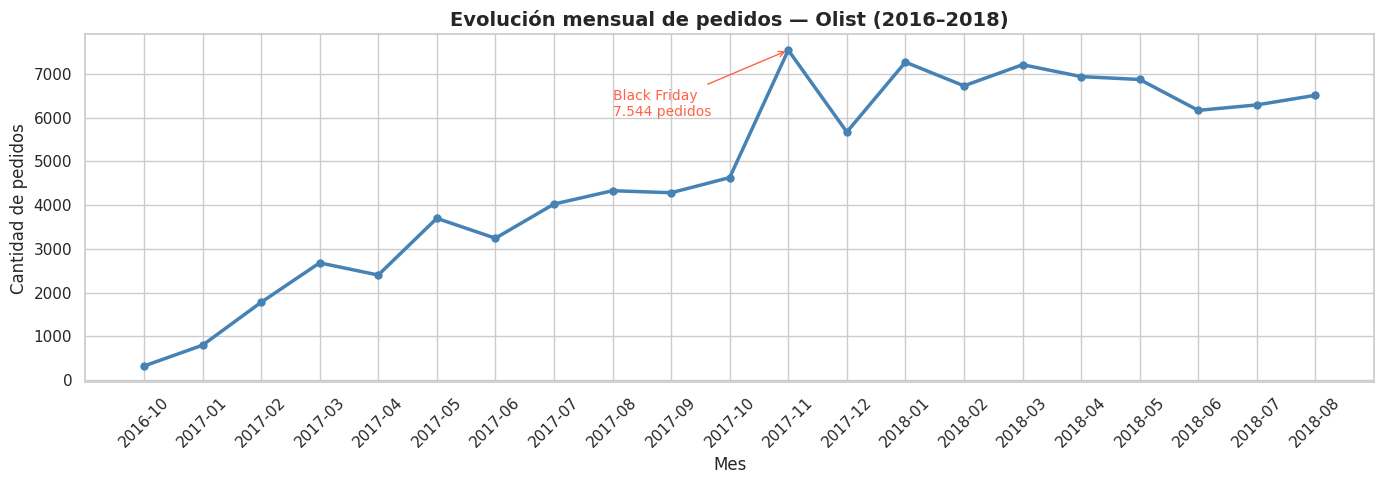

In [45]:
# ============================================================
# EDA — Bloque 1: Evolución mensual de pedidos (2016–2018)
# ------------------------------------------------------------
# Se excluyen meses incompletos en los extremos del dataset
# (2016-09, 2016-12, 2018-09, 2018-10) para no distorsionar
# la lectura de la tendencia.
# ============================================================

meses_excluir = ['2016-09', '2016-12', '2018-09', '2018-10']
df_plot = pedidos_por_mes[
    ~pedidos_por_mes['year_month_str'].isin(meses_excluir)
].copy()

meses = df_plot['year_month_str'].tolist()
pos_pico = meses.index('2017-11')
val_pico = df_plot[df_plot['year_month_str'] == '2017-11']['total_pedidos'].values[0]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    df_plot['year_month_str'],
    df_plot['total_pedidos'],
    color='steelblue',
    linewidth=2.5,
    marker='o',
    markersize=5
)

ax.annotate(
    'Black Friday\n7.544 pedidos',
    xy=(pos_pico, val_pico),
    xytext=(pos_pico - 3, val_pico - 1500),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato',
    fontsize=10
)

ax.set_title('Evolución mensual de pedidos — Olist (2016–2018)')
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de pedidos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### Evolución mensual de pedidos

El volumen de pedidos creció de forma sostenida entre 2016 y 2018,
pasando de ~800 pedidos mensuales a principios de 2017 a más de 7.000
a principios de 2018. Se destaca un pico en noviembre 2017 asociado
al Black Friday, evento que impacta fuertemente en el e-commerce brasileño.

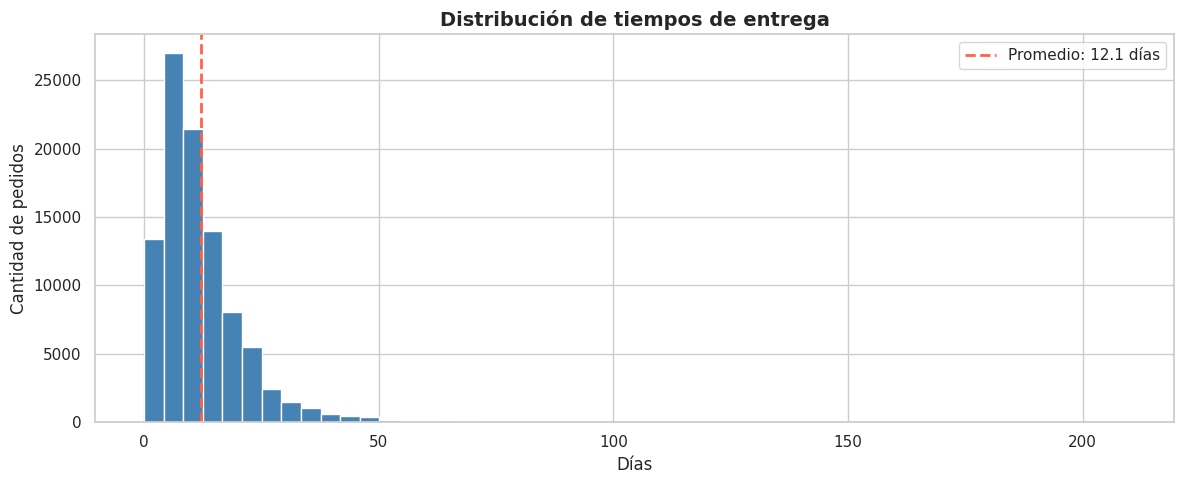

In [46]:
# EDA — Bloque 2: Distribución de tiempos de entrega

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    orders_delivered['delivery_days'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)

ax.axvline(orders_delivered['delivery_days'].mean(),
           color='tomato', linestyle='--', linewidth=2,
           label=f"Promedio: {orders_delivered['delivery_days'].mean():.1f} días")

ax.set_title('Distribución de tiempos de entrega')
ax.set_xlabel('Días')
ax.set_ylabel('Cantidad de pedidos')
ax.legend()
plt.tight_layout()
plt.show()

#### Tiempos de entrega

La mayoría de los pedidos se entrega entre 5 y 20 días desde la compra,
con un promedio de 12.1 días. La distribución presenta una cola derecha
pronunciada, indicando la existencia de casos atípicos con tiempos de
entrega muy elevados (hasta 209 días) que no representan el comportamiento
habitual del negocio.

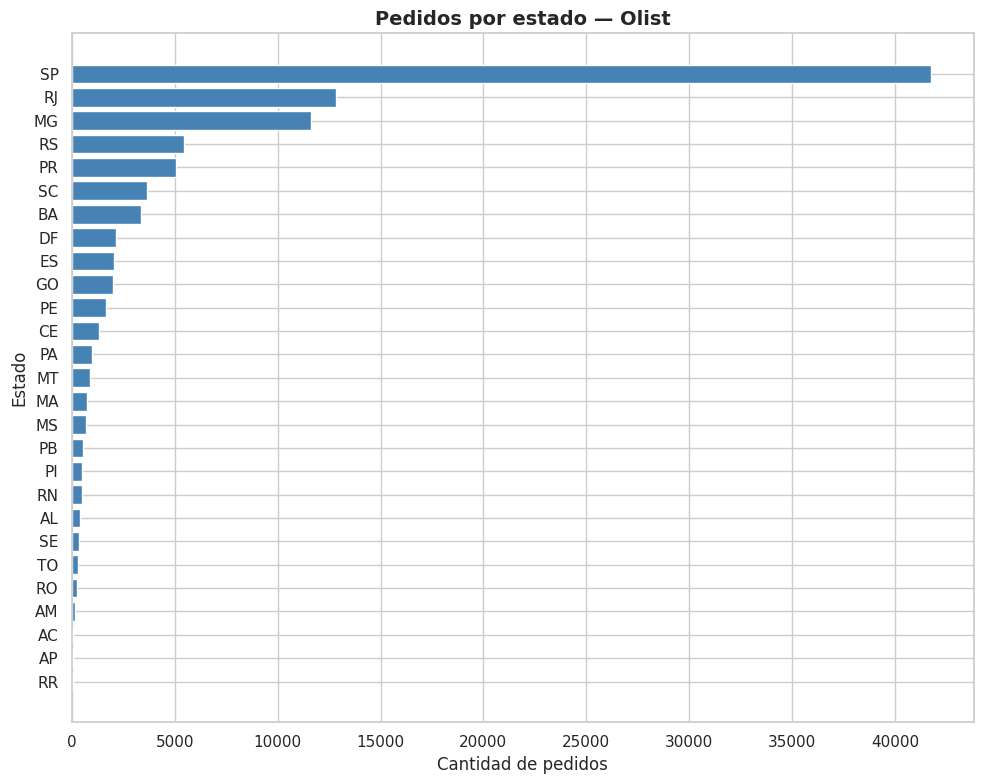

In [47]:
# EDA — Bloque 3: Pedidos por estado

# Uno orders con customers para obtener el estado
orders_geo = orders.merge(customers[['customer_id', 'customer_state']],
                          on='customer_id', how='left')

pedidos_por_estado = (
    orders_geo.groupby('customer_state')
    .size()
    .reset_index(name='total_pedidos')
    .sort_values('total_pedidos', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    pedidos_por_estado['customer_state'],
    pedidos_por_estado['total_pedidos'],
    color='steelblue'
)

ax.set_title('Pedidos por estado — Olist')
ax.set_xlabel('Cantidad de pedidos')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

#### Pedidos por estado

São Paulo concentra la mayor parte de los pedidos, reflejando su peso
económico y poblacional en Brasil. Le siguen Rio de Janeiro y Minas Gerais.
Los estados del norte y noreste muestran volúmenes significativamente
menores, lo que puede estar relacionado tanto con menor penetración
del e-commerce como con dificultades logísticas en esas regiones.

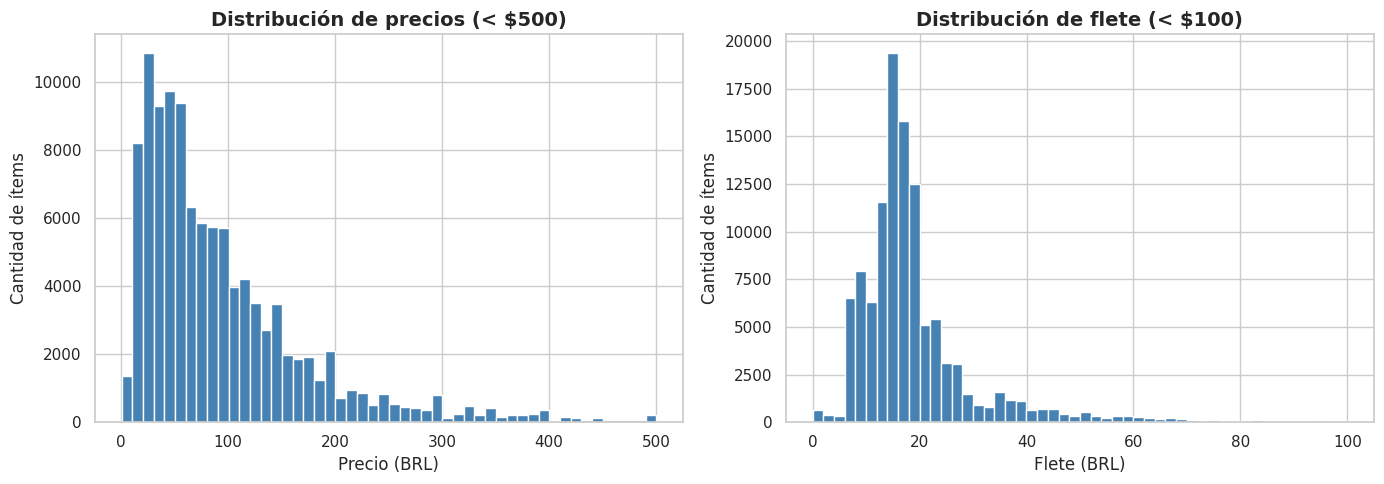

In [48]:
# EDA — Bloque 4: Distribución de precio y flete

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precio (filtro outliers extremos para mejor visualización)
axes[0].hist(
    items[items['price'] < 500]['price'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Distribución de precios (< $500)')
axes[0].set_xlabel('Precio (BRL)')
axes[0].set_ylabel('Cantidad de ítems')

# Flete
axes[1].hist(
    items[items['freight_value'] < 100]['freight_value'],
    bins=50,
    color='steelblue',
    edgecolor='white'
)
axes[1].set_title('Distribución de flete (< $100)')
axes[1].set_xlabel('Flete (BRL)')
axes[1].set_ylabel('Cantidad de ítems')

plt.tight_layout()
plt.show()

#### Precios y costos de envío

La mayoría de los productos tienen un precio de entre 20 y 100 BRL,
con una cola derecha que indica la presencia de productos de alto valor.
El costo de flete se concentra entre 10 y 30 BRL. Ambas distribuciones
presentan outliers que serán considerados al momento de calcular promedios
y construir el dashboard.

## SÍNTESIS DEL ANÁLISIS

| Dimensión | Hallazgo principal |
|---|---|
| Volumen temporal | Crecimiento sostenido en 2017–2018, pico en Black Friday |
| Tiempos de entrega | Promedio 12.1 días, con casos extremos de hasta 209 días |
| Geografía | SP concentra la mayor demanda, norte del país con baja actividad |
| Precios y flete | Productos de ticket bajo-medio, flete entre 10 y 30 BRL |

In [49]:
# Exportar datasets limpios para Power BI

orders_dashboard = orders.merge(
    customers[['customer_id', 'customer_state', 'customer_city']],
    on='customer_id',
    how='left'
)

orders_dashboard = orders_dashboard.merge(
    orders_delivered[['order_id', 'delivery_days']],
    on='order_id',
    how='left'
)

items_agg = items.groupby('order_id').agg(
    precio_total=('price', 'sum'),
    flete_total=('freight_value', 'sum')
).reset_index()

orders_dashboard = orders_dashboard.merge(
    items_agg,
    on='order_id',
    how='left'
)

orders_dashboard.to_csv('/content/drive/MyDrive/olist_dashboard.csv', index=False)

print(f"✅ Archivo exportado: {orders_dashboard.shape[0]:,} filas | {orders_dashboard.shape[1]} columnas")
print("\nColumnas:")
print(orders_dashboard.columns.tolist())

✅ Archivo exportado: 99,441 filas | 14 columnas

Columnas:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'year_month', 'customer_state', 'customer_city', 'delivery_days', 'precio_total', 'flete_total']
